In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path + Setup

In [275]:
#set path + read into dataframe
path = r'../rotterdam_dataset_06.xlsx'
rd = pd.read_excel(path)

#rename for easiness
rd = rd.rename(columns = {'Arrival_Date': 'arrival_date','Vessel_ID':'vessel_id','Vessel_Type':'vessel_type', 'Cargo_tons':'cargo_tons',
                         'Berth_Time_hr':'berth_time_hr'})

## Summary statistics

In [285]:
#gather general statistics
rd.info()
rd.describe()

<class 'pandas.DataFrame'>
RangeIndex: 19627 entries, 0 to 19626
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   arrival_date   19627 non-null  datetime64[us]
 1   vessel_id      19627 non-null  str           
 2   vessel_type    19627 non-null  str           
 3   cargo_tons     19627 non-null  int64         
 4   berth_time_hr  19627 non-null  float64       
 5   year           19627 non-null  str           
 6   year_month     19627 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 1.0 MB


,arrival_date,cargo_tons,berth_time_hr
count,19627,19627.000000,19627.000000
mean,2023-07-03 13:10:25.098079,30121.069598,27.493050
min,2022-01-01 08:00:00,3493.000000,8.500000
25%,2022-09-26 02:31:00,17039.000000,20.800000
50%,2023-07-02 06:11:00,27391.000000,27.100000
75%,2024-04-08 01:49:00,40284.000000,34.300000
max,2024-12-31 23:37:00,114173.000000,46.800000
std,NaN,15790.387144,7.581659


## Checking for nulls/duplicates

In [61]:
#check each column whether any null values
print(rd.isnull().sum())

#duplicate check via uniqueness
print(rd['vessel_id'].nunique())

arrival_date     0
vessel_id        0
vessel_type      0
cargo_tons       0
berth_time_hr    0
month            0
monthday         0
dtype: int64
19627


In [288]:
#maybe there are some vessel_ids that are not unique; check via comparison of cargo_tons/berth_time_hr and see
rd2 = rd

#if there are less than 19627 entries then there are duplicates
unique = rd2.merge(rd, on =['arrival_date', 'vessel_type', 'cargo_tons',
                            'year_month', 'year', 'berth_time_hr'])
unique.info()
unique.head()


<class 'pandas.DataFrame'>
RangeIndex: 19627 entries, 0 to 19626
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   arrival_date   19627 non-null  datetime64[us]
 1   vessel_id_x    19627 non-null  str           
 2   vessel_type    19627 non-null  str           
 3   cargo_tons     19627 non-null  int64         
 4   berth_time_hr  19627 non-null  float64       
 5   year           19627 non-null  str           
 6   year_month     19627 non-null  str           
 7   vessel_id_y    19627 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 1.2 MB


,arrival_date,vessel_id_x,vessel_type,cargo_tons,berth_time_hr,year,year_month,vessel_id_y
0,2022-01-01 11:56:00,V000001,Container,20095,19.6,2022,2022-01,V000001
1,2022-01-01 16:11:00,V000002,Container,11949,21.6,2022,2022-01,V000002
2,2022-01-01 12:31:00,V000003,Container,12465,17.3,2022,2022-01,V000003
3,2022-01-01 09:32:00,V000004,Container,38001,14.2,2022,2022-01,V000004
4,2022-01-01 10:20:00,V000005,Container,11270,17.7,2022,2022-01,V000005


## Graph

In [278]:
#set style for consistency
sns.set_theme(style = 'darkgrid')
palette = sns.color_palette('colorblind')
sns.set_palette('colorblind')

In [279]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [280]:
#create new col in df in order to later plot
rd['year'] = rd['arrival_date'].dt.strftime('%Y')
rd['year_month'] = rd['arrival_date'].dt.strftime('%Y-%m')
rd.head()

,arrival_date,vessel_id,vessel_type,cargo_tons,berth_time_hr,year,year_month
0,2022-01-01 11:56:00,V000001,Container,20095,19.6,2022,2022-01
1,2022-01-01 16:11:00,V000002,Container,11949,21.6,2022,2022-01
2,2022-01-01 12:31:00,V000003,Container,12465,17.3,2022,2022-01
3,2022-01-01 09:32:00,V000004,Container,38001,14.2,2022,2022-01
4,2022-01-01 10:20:00,V000005,Container,11270,17.7,2022,2022-01


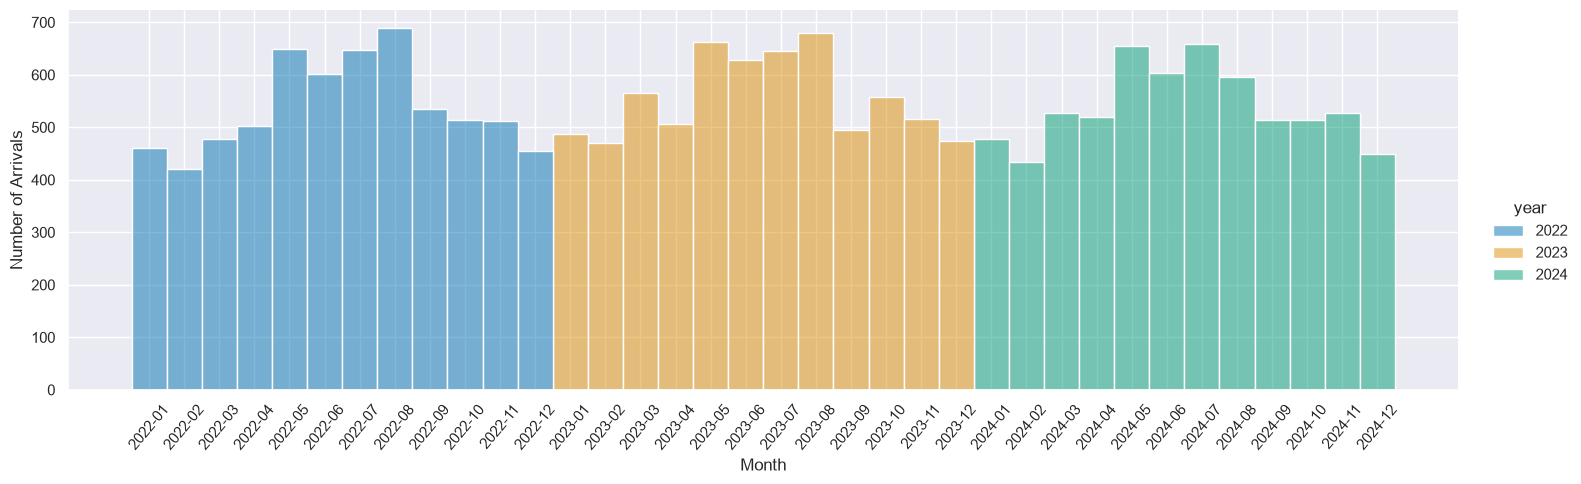

In [290]:
#plotting year_month so i dont have to deal with making
h = sns.displot(data = rd, x = 'year_month', hue = 'year',
                bins = 36, aspect = 3, kind = 'hist')
h.tick_params(axis = 'x', rotation = 50)
h.set_axis_labels('Month', 'Number of Arrivals')
h.tight_layout()
h.savefig('figures/arrivalhist.jpeg')

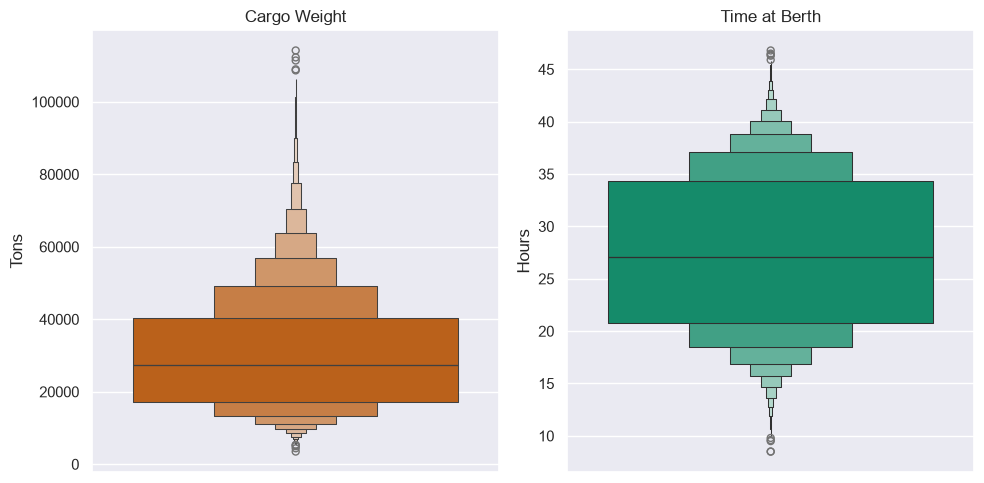

In [282]:
#plots next to each other despite diff scale b/c need space on report
f, ax = plt.subplots(1, 2, figsize = (10, 5))

#boxenplots good for large datasets
sns.boxenplot(y = rd['cargo_tons'], ax = ax[0], color = palette[3])
ax[0].set_title('Cargo Weight')
ax[0].set_ylabel('Tons')

sns.boxenplot(y = rd['berth_time_hr'], ax = ax[1], color = palette[2])
ax[1].set_title('Time at Berth')
ax[1].set_ylabel('Hours')

#save/layout
plt.tight_layout()
plt.savefig('figures/boxenplots.jpeg', bbox_inches='tight')
plt.show()

## Outliers

In [283]:
#first cargo weight

q3 = rd['cargo_tons'].quantile(0.75)
q1 = rd['cargo_tons'].quantile(0.25)

#outlier = val>q3 or val<q1
outlier_cargo = rd[(rd['cargo_tons'] > q3) | (rd['cargo_tons'] < q1)]
print(len(outlier_cargo))
#print b/c otherwise notebook doesn't print all
print(outlier_cargo.describe())

#checking above/below both to see if consistent w idea that cargo high = berth time high
above_cargo = rd[rd['cargo_tons'] > q3]
print(above_cargo.describe())

below_cargo = rd[rd['cargo_tons'] < q1]
print(below_cargo.describe())


9811
                     arrival_date     cargo_tons  berth_time_hr
count                        9811    9811.000000    9811.000000
mean   2023-07-03 02:46:38.772806   32497.946387      27.249322
min           2022-01-01 08:00:00    3493.000000       8.500000
25%           2022-09-27 12:45:00   13213.500000      20.400000
50%           2023-07-02 11:40:00   17035.000000      26.300000
75%           2024-04-06 11:23:30   49227.000000      34.600000
max           2024-12-31 23:37:00  114173.000000      46.800000
std                           NaN   20984.826611       7.823996
                     arrival_date     cargo_tons  berth_time_hr
count                        4905    4905.000000    4905.000000
mean   2023-06-29 16:16:13.088685   52041.542712      33.783792
min           2022-01-01 08:00:00   40289.000000      14.800000
25%           2022-09-27 12:49:00   44278.000000      30.700000
50%           2023-07-01 13:11:00   49228.000000      34.600000
75%           2024-03-28 20:14:00  

In [284]:
#berth_time_hr

q3 = rd['berth_time_hr'].quantile(0.75)
q1 = rd['berth_time_hr'].quantile(0.25)

outlier_berth = rd[(rd['berth_time_hr'] > q3) | (rd['berth_time_hr'] < q1)]
print(outlier_berth.describe())

above_berth = rd[rd['berth_time_hr'] > q3]
print(above_berth.describe())

below_berth = rd[rd['berth_time_hr'] < q1]
print(below_berth.describe())

                     arrival_date     cargo_tons  berth_time_hr
count                        9755    9755.000000    9755.000000
mean   2023-07-05 08:53:50.251153   30108.331010      27.809298
min           2022-01-01 08:00:00    4400.000000       8.500000
25%           2022-09-28 05:34:30   16254.000000      18.500000
50%           2023-07-05 05:09:00   26658.000000      34.400000
75%           2024-04-08 07:45:00   41175.500000      37.100000
max           2024-12-31 12:20:00  114173.000000      46.800000
std                           NaN   16403.692378       9.911579
                     arrival_date     cargo_tons  berth_time_hr
count                        4899    4899.000000    4899.000000
mean   2023-07-06 06:10:53.410900   42798.137579      37.458012
min           2022-01-01 08:00:00    6672.000000      34.400000
25%           2022-10-03 02:02:00   33444.000000      35.800000
50%           2023-07-06 01:00:00   40938.000000      37.100000
75%           2024-04-07 15:57:30   5001

In [187]:
#intersection
both_above = above_berth.merge(above_cargo, on = ['vessel_id', 'arrival_date', 'vessel_type', 'cargo_tons',
                                                  'year_month', 'year', 'berth_time_hr'])
print(both_above.describe())

#intersection
both_below = below_berth.merge(below_cargo, on = ['vessel_id', 'arrival_date', 'vessel_type', 'cargo_tons',
                                                  'year_month', 'year', 'berth_time_hr'])
print(both_below.describe())

                     arrival_date     cargo_tons  berth_time_hr
count                        2562    2562.000000    2562.000000
mean   2023-07-06 13:15:52.482435   52364.931694      37.437822
min           2022-01-01 08:00:00   40290.000000      34.400000
25%           2022-10-02 13:37:30   44567.500000      35.800000
50%           2023-07-05 17:26:00   49636.500000      37.100000
75%           2024-04-06 03:11:45   57513.500000      38.700000
max           2024-12-31 12:20:00  114173.000000      46.800000
std                           NaN   10398.927626       2.139364
                     arrival_date    cargo_tons  berth_time_hr
count                        2678   2678.000000    2678.000000
mean   2023-07-08 23:07:20.993278  12892.037341      18.065945
min           2022-01-01 10:20:00   4400.000000       8.500000
25%           2022-09-27 04:27:30  11049.250000      16.900000
50%           2023-07-10 03:28:00  13098.000000      18.500000
75%           2024-04-17 00:05:15  15073.75000

pandas.DataFrame

In [291]:
#set difference above_cargo - both_above
inconsistent_cargo_above = above_cargo[~above_cargo.index.isin(both_above.index)]
print(inconsistent_cargo_above.info())

#this is wrong plz ignore need to figure out but later section

<class 'pandas.DataFrame'>
Index: 4285 entries, 2562 to 19624
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   arrival_date   4285 non-null   datetime64[us]
 1   vessel_id      4285 non-null   str           
 2   vessel_type    4285 non-null   str           
 3   cargo_tons     4285 non-null   int64         
 4   berth_time_hr  4285 non-null   float64       
 5   year           4285 non-null   str           
 6   year_month     4285 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 267.8 KB
None
